# 1. Environment Setup & Configuration

In [1]:
!pip install -q diffusers accelerate opencv-python torchmetrics

import os
import shutil
import time
import math
import warnings
import zipfile

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch import amp
import torchvision.transforms as transforms
from torchvision.utils import save_image

from torchmetrics import StructuralSimilarityIndexMeasure, PeakSignalNoiseRatio
from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity
from google.colab import drive
from diffusers import UNet2DModel, RePaintPipeline, RePaintScheduler, DDPMScheduler
from diffusers.optimization import get_cosine_schedule_with_warmup

# Configuration constants
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 100
LEARNING_RATE = 1e-4
GRAD_ACCUMULATION_STEPS = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Suppress minor warnings for cleaner logs
warnings.filterwarnings("ignore")

print(f"[Config] Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"[Config] GPU: {torch.cuda.get_device_name(0)}")

torch.backends.cudnn.benchmark = True

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 57.7 MB/s eta 0:00:00
[Config] Device: cuda
[Config] GPU: NVIDIA A100-SXM4-80GB


# 2. Data Preparation

In [2]:
def prepare_dataset(source_zip_path: str, extract_path: str) -> None:
    """
    Extract a zipped dataset from Google Drive to a local path if not already extracted.

    Args:
        source_zip_path: Full path to the zip file in Google Drive.
        extract_path: Local directory where the dataset should be extracted.
    """
    if os.path.exists(extract_path):
        print(f"[Data] Dataset already exists at {extract_path}")
        return

    print(f"[Data] Extracting {source_zip_path} to {extract_path}...")
    temp_zip = "/content/temp_dataset.zip"
    shutil.copy(source_zip_path, temp_zip)
    os.system(f"unzip -q {temp_zip} -d {extract_path}")
    os.remove(temp_zip)
    print("[Data] Extraction complete.")

# Mount Drive & define paths
drive.mount("/content/drive")

DRIVE_BASE = "/content/drive/My Drive/computer-vision/dataset"
PROJECT_BASE = "/content/drive/My Drive/computer-vision"
OUTPUT_IMG_DIR = os.path.join(PROJECT_BASE, "output_repaint", "images")
OUTPUT_MODEL_DIR = os.path.join(PROJECT_BASE, "output_repaint", "saved_models")

os.makedirs(OUTPUT_IMG_DIR, exist_ok=True)
os.makedirs(OUTPUT_MODEL_DIR, exist_ok=True)

# Extract datasets
prepare_dataset(
    os.path.join(DRIVE_BASE, "triplets_out.zip"),
    "/content/triplets_out"
)

prepare_dataset(
    os.path.join(DRIVE_BASE, "triplets_val_OTI.zip"),
    "/content/triplets_val_OTI"
)

hti_zip = os.path.join(DRIVE_BASE, "triplets_HTI.zip")
if os.path.exists(hti_zip):
    prepare_dataset(hti_zip, "/content/triplets_HTI")

print(f"[Path] Images will be saved to:  {OUTPUT_IMG_DIR}")
print(f"[Path] Models will be saved to:  {OUTPUT_MODEL_DIR}")

Mounted at /content/drive
[Data] Extracting /content/drive/My Drive/computer-vision/dataset/triplets_out.zip to /content/triplets_out...
[Data] Extraction complete.
[Data] Extracting /content/drive/My Drive/computer-vision/dataset/triplets_val_OTI.zip to /content/triplets_val_OTI...
[Data] Extraction complete.
[Data] Extracting /content/drive/My Drive/computer-vision/dataset/triplets_HTI.zip to /content/triplets_HTI...
[Data] Extraction complete.
[Path] Images will be saved to:  /content/drive/My Drive/computer-vision/output_repaint/images
[Path] Models will be saved to:  /content/drive/My Drive/computer-vision/output_repaint/saved_models


In [3]:
class EmojiInpaintingDataset(Dataset):
    """
    Dataset for emoji inpainting triplets.

    Each sample consists of:
        - erased_img: input image with missing region
        - orig_img: original target image
        - mask_tensor: binary mask of missing region (1 = hole)
        - filename: name of the erased image file (used for saving outputs)
    """

    def __init__(self, root_dir: str, transform=None):
        """
        Args:
            root_dir: Root directory containing index.csv and image files.
            transform: Torchvision transform to apply to RGB images.
        """
        self.root_dir = root_dir
        self.csv_file = os.path.join(root_dir, "index.csv")
        self.data = pd.read_csv(self.csv_file)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int):
        """
        Fetch a single training or evaluation sample.

        Returns:
            Tuple (erased_img, orig_img, mask_tensor, filename)
        """
        row = self.data.iloc[idx]

        erased_path = os.path.join(self.root_dir, row["erased"])
        orig_path = os.path.join(self.root_dir, row["orig"])
        mask_path = os.path.join(self.root_dir, row["mask"])

        filename = os.path.basename(erased_path)

        erased_img = Image.open(erased_path).convert("RGB")
        orig_img = Image.open(orig_path).convert("RGB")
        mask_img = Image.open(mask_path).convert("L")

        erased_img = erased_img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        orig_img = orig_img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        mask_img = mask_img.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)

        if self.transform:
            erased_img = self.transform(erased_img)
            orig_img = self.transform(orig_img)

        mask = np.array(mask_img)
        mask = (mask > 128).astype(np.float32)
        mask_tensor = torch.tensor(mask).unsqueeze(0)

        return erased_img, orig_img, mask_tensor, filename

# Transforms
base_transforms = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

# DataLoaders
train_dataset = EmojiInpaintingDataset("/content/triplets_out", transform=base_transforms)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
)

val_dataset = EmojiInpaintingDataset("/content/triplets_val_OTI", transform=base_transforms)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True
)

print(f"[Data] Train size: {len(train_dataset)}")
print(f"[Data] Val (OTI) size: {len(val_dataset)}")

[Data] Train size: 3440
[Data] Val (OTI) size: 20


# 3. Model Architecture

In [4]:
train_scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_start=0.0001,
    beta_end=0.02,
    beta_schedule="linear",
)

inference_scheduler = RePaintScheduler(
    num_train_timesteps=1000,
    beta_start=0.0001,
    beta_end=0.02,
    beta_schedule="linear",
)

model = UNet2DModel(
    sample_size=IMG_SIZE,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 64, 128, 128, 256, 256),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
).to(DEVICE)

model.enable_gradient_checkpointing()
print("[Model] Diffusion UNet initialized.")

[Model] Diffusion UNet initialized.


# 4. Training Loop

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scaler = amp.GradScaler("cuda")

steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUMULATION_STEPS)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=500,
    num_training_steps=(steps_per_epoch * EPOCHS),
)

def save_snapshot(model: UNet2DModel, epoch: int, output_dir: str, num_samples: int = 4) -> None:
    """
    Run a quick snapshot on the validation set, save a grid to disk,
    and display it inline in the notebook.

    Layout:
        Row 1: input (erased)
        Row 2: prediction (inpainted)
        Row 3: ground truth (original)
    """
    model.eval()
    pipeline = RePaintPipeline(unet=model, scheduler=inference_scheduler)
    pipeline.set_progress_bar_config(disable=True)

    # Take one batch from validation set
    erased, real, mask, _ = next(iter(val_loader))
    erased = erased.to(DEVICE)
    real = real.to(DEVICE)
    mask = mask.to(DEVICE)

    # Limit to num_samples
    num_samples = min(num_samples, erased.size(0))

    with torch.no_grad():
        generated = pipeline(
            image=erased[:num_samples],
            mask_image=mask[:num_samples],
            num_inference_steps=50,
            eta=0.0,
            output_type="pt",
        ).images

    # Ensure tensor type (handle numpy output)
    if not isinstance(generated, torch.Tensor):
        generated = torch.from_numpy(generated)

    # NHWC -> NCHW if needed
    if generated.ndim == 4 and generated.shape[-1] == 3:
        generated = generated.permute(0, 3, 1, 2)

    generated = generated.to(DEVICE)

    # Build grid: first all inputs, then preds, then GT
    # Row 1: erased, Row 2: generated, Row 3: real
    grid = torch.cat(
        [
            erased[:num_samples],
            generated[:num_samples],
            real[:num_samples],
        ],
        dim=0,
    )

    snapshot_path = os.path.join(output_dir, f"epoch_{epoch:03d}_snapshot.png")

    # nrow = num_samples -> 3 rows (input, pred, GT), no black tiles
    save_image(
        grid,
        snapshot_path,
        nrow=num_samples,
        normalize=True,
        value_range=(-1, 1),
    )

    print(f"[Snapshot] Saved validation snapshot to {snapshot_path}")

    # Display snapshot inline
    img_grid = mpimg.imread(snapshot_path)
    plt.figure(figsize=(3 * num_samples, 6))
    plt.imshow(img_grid)
    plt.axis("off")
    plt.title(f"Validation snapshot - epoch {epoch:03d}\nRow1: Input | Row2: Pred | Row3: GT")
    plt.show()

    del pipeline

print(f"[Train] Starting training for {EPOCHS} epochs...")
start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    for step, (erased_imgs, orig_imgs, _, _) in enumerate(train_loader):
        clean_images = orig_imgs.to(DEVICE)
        batch_size = clean_images.shape[0]

        with amp.autocast(device_type="cuda"):
            noise = torch.randn(clean_images.shape).to(DEVICE)
            timesteps = torch.randint(
                0, train_scheduler.config.num_train_timesteps, (batch_size,), device=DEVICE
            ).long()

            noisy_images = train_scheduler.add_noise(clean_images, noise, timesteps)
            noise_pred = model(noisy_images, timesteps, return_dict=False)[0]

            loss = F.mse_loss(noise_pred, noise)
            loss = loss / GRAD_ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            lr_scheduler.step()

        epoch_loss += loss.item() * GRAD_ACCUMULATION_STEPS

    avg_loss = epoch_loss / len(train_loader)
    elapsed_min = (time.time() - start_time) / 60.0
    print(
        f"[Train] Epoch {epoch + 1:03d}/{EPOCHS} | "
        f"Loss: {avg_loss:.6f} | Elapsed: {elapsed_min:.1f} min"
    )

    if (epoch + 1) % 10 == 0:
        save_path = os.path.join(OUTPUT_MODEL_DIR, f"repaint_epoch_{epoch + 1}")
        pipeline = RePaintPipeline(unet=model, scheduler=inference_scheduler)
        pipeline.save_pretrained(save_path)
        print(f"[Checkpoint] Saved model to {save_path}")
        save_snapshot(model, epoch + 1, OUTPUT_IMG_DIR, num_samples=4)

print("[Train] Training complete.")

Output hidden; open in https://colab.research.google.com to view.

# 5. Evaluation & Metrics

## 5.1. Evaluate OTI (Open Test Images)

In [10]:
def evaluate_and_save(
    model_path: str,
    dataset_path: str,
    output_name: str,
    save_individual_images: bool = True,
) -> pd.DataFrame:
    """
    Evaluate a trained model on a dataset, compute metrics, and generate visual outputs.

    This function:
        1. Runs RePaint inference for each sample.
        2. Computes PSNR, SSIM, and LPIPS.
        3. Optionally saves reconstructed images.
        4. Saves metrics to CSV.
        5. Builds a composite grid visualization.
    """
    print(f"\n[Eval] Start evaluation: {output_name}")
    print(f"[Eval] Dataset path: {dataset_path}")
    print(f"[Eval] Loading dataset and model...")

    eval_dataset = EmojiInpaintingDataset(dataset_path, transform=base_transforms)
    eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False)

    result_dir = os.path.join(PROJECT_BASE, "results", output_name)
    img_save_dir = os.path.join(result_dir, "reconstructed_images")
    os.makedirs(result_dir, exist_ok=True)
    if save_individual_images:
        os.makedirs(img_save_dir, exist_ok=True)

    pipeline = RePaintPipeline.from_pretrained(model_path).to(DEVICE)
    pipeline.scheduler = RePaintScheduler.from_config(pipeline.scheduler.config)
    pipeline.set_progress_bar_config(disable=True)

    # Metrics on same device as model
    psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(DEVICE)
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(DEVICE)
    lpips_metric = LearnedPerceptualImagePatchSimilarity(
        net_type="vgg", normalize=True
    ).to(DEVICE)

    results = []
    visual_triplets = []

    print(f"[Eval] Total images: {len(eval_dataset)}")

    # Small warmup
    _ = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

    with torch.no_grad():
        for batch_idx, (v_erased, v_real, v_mask, filenames) in enumerate(eval_loader):
            v_erased = v_erased.to(DEVICE)
            v_real = v_real.to(DEVICE)
            v_mask = v_mask.to(DEVICE)

            for j in range(v_real.shape[0]):
                img = v_erased[j].unsqueeze(0)
                mask = v_mask[j].unsqueeze(0)
                real_target = v_real[j].unsqueeze(0)
                fname = filenames[j]

                start_ts = time.time()
                output = pipeline(
                    image=img,
                    mask_image=mask,
                    num_inference_steps=50,
                    jump_length=10,
                    jump_n_sample=10,
                    eta=0.0,
                    output_type="pt",
                ).images
                end_ts = time.time()

                if not isinstance(output, torch.Tensor):
                    output = torch.from_numpy(output)

                if output.ndim == 4 and output.shape[-1] == 3:
                    output = output.permute(0, 3, 1, 2)

                output = output.to(DEVICE)

                pred = torch.clamp((output + 1) / 2, 0, 1)
                target = torch.clamp((real_target + 1) / 2, 0, 1)
                inp = torch.clamp((img + 1) / 2, 0, 1)

                psnr_val = psnr_metric(pred, target).item()
                ssim_val = ssim_metric(pred, target).item()
                lpips_val = lpips_metric(pred, target).item()

                results.append(
                    {
                        "filename": fname,
                        "psnr": psnr_val,
                        "ssim": ssim_val,
                        "lpips": lpips_val,
                        "time": end_ts - start_ts,
                    }
                )

                if save_individual_images:
                    save_path = os.path.join(img_save_dir, fname)
                    save_image(output.cpu(), save_path, normalize=True, value_range=(-1, 1))

                triplet = torch.cat([inp, pred, target], dim=3)
                visual_triplets.append(triplet.cpu())

            if (batch_idx + 1) % 5 == 0 or (batch_idx + 1) == len(eval_loader):
                print(
                    f"[Eval] Processed batch {batch_idx + 1}/{len(eval_loader)} "
                    f"({(batch_idx + 1) * BATCH_SIZE}/{len(eval_dataset)} images approx.)"
                )

    df = pd.DataFrame(results)
    csv_path = os.path.join(result_dir, f"metrics_{output_name}.csv")
    df.to_csv(csv_path, index=False)
    print(f"[Eval] Metrics saved to {csv_path}")

    if len(visual_triplets) > 0:
        all_triplets = torch.cat(visual_triplets, dim=0)
        grid_path = os.path.join(result_dir, f"overview_grid_{output_name}.png")

        save_image(
            all_triplets,
            grid_path,
            nrow=2,
            padding=5,
            pad_value=1.0,
            value_range=(-1, 1),
        )
        print(f"[Visual] Composite grid saved to {grid_path}")

        img_grid = mpimg.imread(grid_path)
        plt.figure(figsize=(24, max(4, len(visual_triplets) * 0.75)))
        plt.imshow(img_grid)
        plt.axis("off")
        plt.title(
            f"{output_name} results (Left: Input | Center: Prediction | Right: Ground Truth)"
        )
        plt.show()

    print(f"\n[Eval] Summary for {output_name}:")
    print(f"  Mean PSNR : {df['psnr'].mean():.4f}")
    print(f"  Mean SSIM : {df['ssim'].mean():.4f}")
    print(f"  Mean LPIPS: {df['lpips'].mean():.4f}")

    # Per-image detail print
    print(f"\n[Eval] Per-image metrics for {output_name}:")
    print("-" * 60)
    for _, row in df.iterrows():
        print(
            f"{row['filename']}: "
            f"PSNR={row['psnr']:.2f}, "
            f"SSIM={row['ssim']:.3f}, "
            f"LPIPS={row['lpips']:.3f}, "
            f"time={row['time']:.4f}s"
        )

    return df


[Eval-OTI] Running evaluation on OTI validation set...

[Eval] Start evaluation: OTI
[Eval] Dataset path: /content/triplets_val_OTI
[Eval] Loading dataset and model...


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 241MB/s]


[Eval] Total images: 20
[Eval] Processed batch 3/3 (24/20 images approx.)
[Eval] Metrics saved to /content/drive/My Drive/computer-vision/results/OTI/metrics_OTI.csv
[Visual] Composite grid saved to /content/drive/My Drive/computer-vision/results/OTI/overview_grid_OTI.png


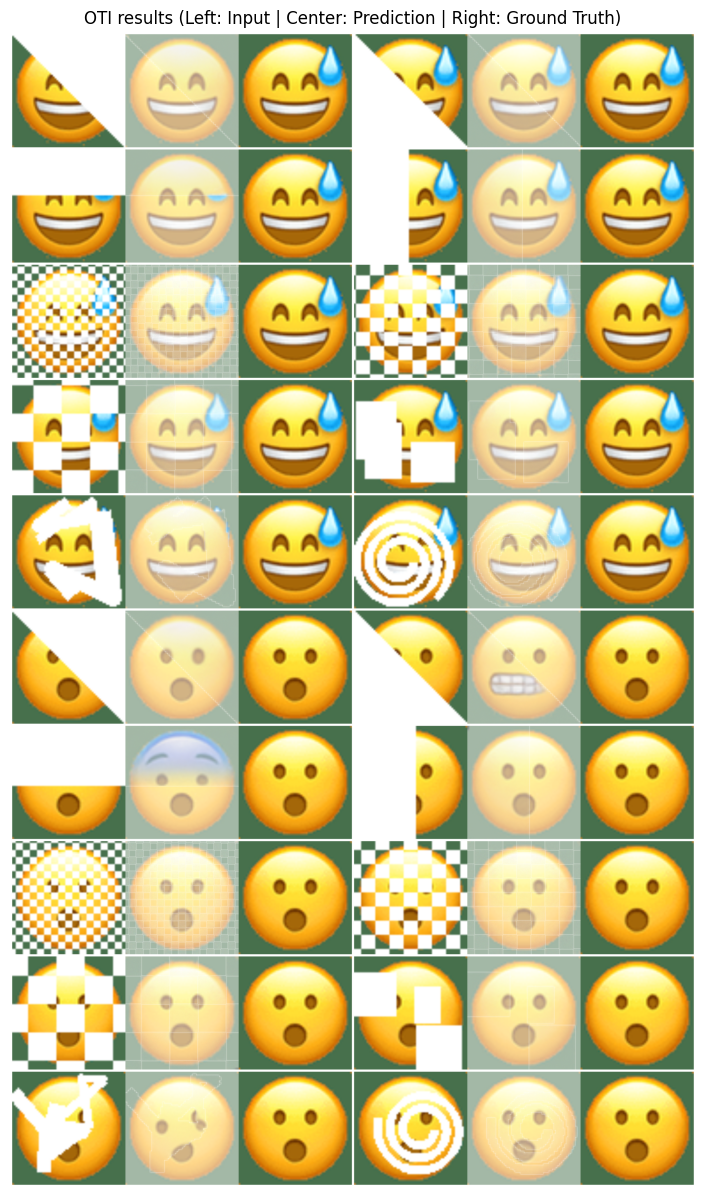


[Eval] Summary for OTI:
  Mean PSNR : 10.4400
  Mean SSIM : 0.7010
  Mean LPIPS: 0.3188

[Eval] Per-image metrics for OTI:
------------------------------------------------------------
6__val_m00_erased.png: PSNR=10.45, SSIM=0.709, LPIPS=0.267, time=12.5035s
6__val_m01_erased.png: PSNR=10.76, SSIM=0.741, LPIPS=0.184, time=12.5152s
6__val_m02_erased.png: PSNR=10.58, SSIM=0.726, LPIPS=0.208, time=12.7907s
6__val_m03_erased.png: PSNR=10.85, SSIM=0.752, LPIPS=0.156, time=12.7009s
6__val_m04_erased.png: PSNR=9.78, SSIM=0.577, LPIPS=0.543, time=12.7698s
6__val_m05_erased.png: PSNR=10.20, SSIM=0.643, LPIPS=0.465, time=12.6810s
6__val_m06_erased.png: PSNR=10.51, SSIM=0.688, LPIPS=0.349, time=12.6909s
6__val_m07_erased.png: PSNR=10.68, SSIM=0.725, LPIPS=0.213, time=12.8027s
6__val_m08_erased.png: PSNR=10.36, SSIM=0.699, LPIPS=0.291, time=12.7293s
6__val_m09_erased.png: PSNR=10.34, SSIM=0.689, LPIPS=0.317, time=12.7881s
72__val_m00_erased.png: PSNR=10.81, SSIM=0.752, LPIPS=0.209, time=12.4260s
7

In [11]:
last_model_path = os.path.join(OUTPUT_MODEL_DIR, f"repaint_epoch_{EPOCHS}")

if os.path.exists(last_model_path):
    print("\n[Eval-OTI] Running evaluation on OTI validation set...")

    df_oti = evaluate_and_save(
        model_path=last_model_path,
        dataset_path="/content/triplets_val_OTI",
        output_name="OTI",
    )

    # Best/worst based on PSNR (higher is better)
    best_psnr = df_oti.loc[df_oti["psnr"].idxmax()]
    worst_psnr = df_oti.loc[df_oti["psnr"].idxmin()]

    print("\n[Eval-OTI] Per-image extremes (based on PSNR):")
    print("-" * 50)
    print(
        f"Best  : {best_psnr['filename']} | "
        f"PSNR: {best_psnr['psnr']:.2f} | "
        f"SSIM: {best_psnr['ssim']:.3f} | "
        f"LPIPS: {best_psnr['lpips']:.3f}"
    )
    print(
        f"Worst : {worst_psnr['filename']} | "
        f"PSNR: {worst_psnr['psnr']:.2f} | "
        f"SSIM: {worst_psnr['ssim']:.3f} | "
        f"LPIPS: {worst_psnr['lpips']:.3f}"
    )
    print("-" * 50)

    # Best/worst based on SSIM (higher is better)
    best_ssim = df_oti.loc[df_oti["ssim"].idxmax()]
    worst_ssim = df_oti.loc[df_oti["ssim"].idxmin()]

    print("\n[Eval-OTI] Per-image extremes (based on SSIM):")
    print("-" * 50)
    print(
        f"Best  : {best_ssim['filename']} | "
        f"PSNR: {best_ssim['psnr']:.2f} | "
        f"SSIM: {best_ssim['ssim']:.3f} | "
        f"LPIPS: {best_ssim['lpips']:.3f}"
    )
    print(
        f"Worst : {worst_ssim['filename']} | "
        f"PSNR: {worst_ssim['psnr']:.2f} | "
        f"SSIM: {worst_ssim['ssim']:.3f} | "
        f"LPIPS: {worst_ssim['lpips']:.3f}"
    )
    print("-" * 50)

    # Best/worst based on LPIPS (lower is better)
    best_lpips = df_oti.loc[df_oti["lpips"].idxmin()]
    worst_lpips = df_oti.loc[df_oti["lpips"].idxmax()]

    print("\n[Eval-OTI] Per-image extremes (based on LPIPS):")
    print("-" * 50)
    print(
        f"Best  : {best_lpips['filename']} | "
        f"PSNR: {best_lpips['psnr']:.2f} | "
        f"SSIM: {best_lpips['ssim']:.3f} | "
        f"LPIPS: {best_lpips['lpips']:.3f}"
    )
    print(
        f"Worst : {worst_lpips['filename']} | "
        f"PSNR: {worst_lpips['psnr']:.2f} | "
        f"SSIM: {worst_lpips['ssim']:.3f} | "
        f"LPIPS: {worst_lpips['lpips']:.3f}"
    )
    print("-" * 50)
else:
    print("\n[Eval-OTI] Model checkpoint not found.")

## 5.2. Evaluate HTI (Hidden Test Images)

In [12]:
def generate_hti_outputs(
    model_path: str,
    dataset_path: str,
    output_name: str = "HTI",
) -> None:
    """
    Generate inpainted images for the hidden HTI set (no ground truth available).

    - Use erased + mask only
    - Do NOT compute metrics (no orig images)
    - Save reconstructed images with correct submission filenames
    - Build and display a visualization in the notebook
    """
    print(f"\n[Eval-HTI] Start evaluation (generation only): {output_name}")
    print(f"[Eval-HTI] Dataset path: {dataset_path}")
    print("[Eval-HTI] Loading dataset and model...")

    index_path = os.path.join(dataset_path, "index.csv")
    df = pd.read_csv(index_path)
    print(f"[Eval-HTI] Total images: {len(df)}")

    result_dir = os.path.join(PROJECT_BASE, "results", output_name)
    img_save_dir = os.path.join(result_dir, "reconstructed_images")
    os.makedirs(result_dir, exist_ok=True)
    os.makedirs(img_save_dir, exist_ok=True)

    pipeline = RePaintPipeline.from_pretrained(model_path).to(DEVICE)
    pipeline.scheduler = RePaintScheduler.from_config(pipeline.scheduler.config)
    pipeline.set_progress_bar_config(disable=True)

    # Warmup
    _ = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

    times = []
    visual_pairs = []

    with torch.no_grad():
        for i, row in df.iterrows():
            erased_rel = row["erased"]
            mask_rel = row["mask"]

            erased_path = os.path.join(dataset_path, erased_rel)
            mask_path = os.path.join(dataset_path, mask_rel)

            # Erased input
            erased_img = Image.open(erased_path).convert("RGB")
            erased_img = erased_img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
            erased_tensor = base_transforms(erased_img).unsqueeze(0).to(DEVICE)

            # Mask
            mask_img = Image.open(mask_path).convert("L")
            mask_img = mask_img.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
            mask_np = (np.array(mask_img) > 128).astype(np.float32)
            mask_tensor = torch.tensor(mask_np).unsqueeze(0).unsqueeze(0).to(DEVICE)

            # Inference
            start_ts = time.time()
            output = pipeline(
                image=erased_tensor,
                mask_image=mask_tensor,
                num_inference_steps=50,
                jump_length=10,
                jump_n_sample=10,
                eta=0.0,
                output_type="pt",
            ).images
            end_ts = time.time()
            times.append(end_ts - start_ts)

            if not isinstance(output, torch.Tensor):
                output = torch.from_numpy(output)

            if output.ndim == 4 and output.shape[-1] == 3:
                output = output.permute(0, 3, 1, 2)

            output = output.to(DEVICE)

            # Save for submission
            base_name = os.path.basename(erased_rel)
            out_name = base_name.replace("_erased", "")
            save_path = os.path.join(img_save_dir, out_name)
            save_image(output, save_path, normalize=True, value_range=(-1, 1))

            # Build visualization pair in [0, 1]
            inp_vis = torch.clamp((erased_tensor + 1) / 2, 0, 1)
            pred_vis = torch.clamp((output + 1) / 2, 0, 1)

            pair = torch.cat([inp_vis, pred_vis], dim=3)
            visual_pairs.append(pair.cpu())

            if (i + 1) % 10 == 0 or (i + 1) == len(df):
                print(f"[Eval-HTI] Processed {i + 1}/{len(df)} images")

    # Save inference times
    time_df = pd.DataFrame({"time": times})
    time_csv_path = os.path.join(result_dir, "inference_times.csv")
    time_df.to_csv(time_csv_path, index=False)

    print(f"[Eval-HTI] Inference times saved to {time_csv_path}")
    print(f"[Eval-HTI] Reconstructed images saved to: {img_save_dir}")
    print(f"[Eval-HTI] Mean inference time: {time_df['time'].mean():.4f} s")

    # Build and show overview grid
    if len(visual_pairs) > 0:
        all_pairs = torch.cat(visual_pairs, dim=0)
        grid_path = os.path.join(result_dir, f"overview_grid_{output_name}.png")

        save_image(
            all_pairs,
            grid_path,
            nrow=2,
            padding=5,
            pad_value=1.0,
            normalize=False,
        )
        print(f"[Eval-HTI] Overview grid saved to {grid_path}")

        img_grid = mpimg.imread(grid_path)
        plt.figure(figsize=(24, max(4, len(visual_pairs) * 0.75)))
        plt.imshow(img_grid)
        plt.axis("off")
        plt.title(f"{output_name} results (Left: Input | Right: Prediction)")
        plt.show()

[HTI] index.csv not found in /content/triplets_HTI, using nested root: /content/triplets_HTI/triplets_HTI

[Eval-HTI] Running generation on HTI hidden test set...

[Eval-HTI] Start evaluation (generation only): HTI
[Eval-HTI] Dataset path: /content/triplets_HTI/triplets_HTI
[Eval-HTI] Loading dataset and model...
[Eval-HTI] Total images: 40


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

[Eval-HTI] Processed 10/40 images
[Eval-HTI] Processed 20/40 images
[Eval-HTI] Processed 30/40 images
[Eval-HTI] Processed 40/40 images
[Eval-HTI] Inference times saved to /content/drive/My Drive/computer-vision/results/HTI/inference_times.csv
[Eval-HTI] Reconstructed images saved to: /content/drive/My Drive/computer-vision/results/HTI/reconstructed_images
[Eval-HTI] Mean inference time: 12.7081 s
[Eval-HTI] Overview grid saved to /content/drive/My Drive/computer-vision/results/HTI/overview_grid_HTI.png


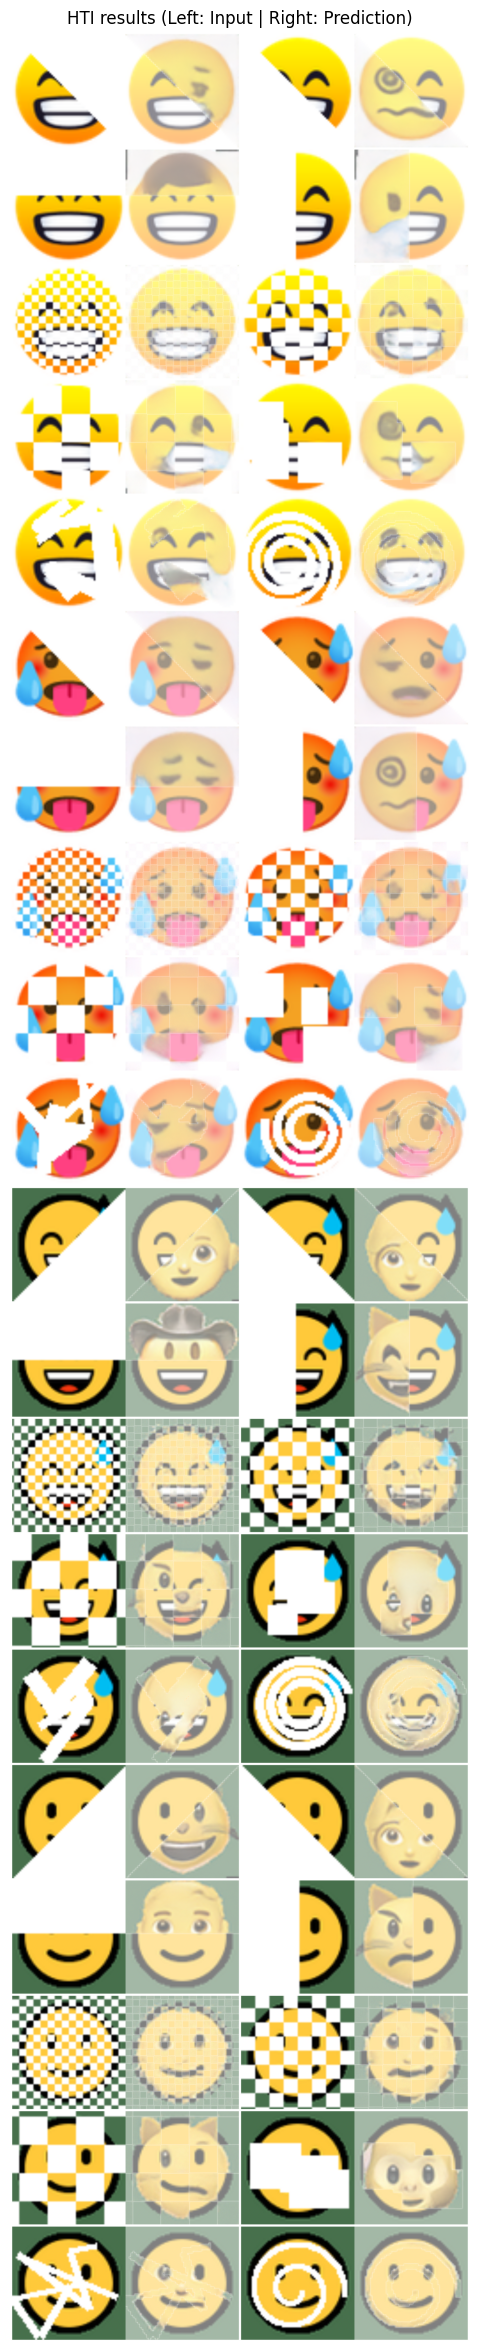


[Eval-HTI] Creating submission archive from /content/drive/My Drive/computer-vision/results/HTI/reconstructed_images...
[Eval-HTI] Submission zip ready: /content/drive/My Drive/computer-vision/CVitamin_HTI.zip


In [13]:
last_model_path = os.path.join(OUTPUT_MODEL_DIR, f"repaint_epoch_{EPOCHS}")

hti_root = "/content/triplets_HTI"
hti_path = hti_root
hti_index = os.path.join(hti_root, "index.csv")

# Handle nested folder case: /content/triplets_HTI/triplets_HTI
if not os.path.exists(hti_index):
    nested = os.path.join(hti_root, "triplets_HTI")
    if os.path.exists(os.path.join(nested, "index.csv")):
        print(f"[HTI] index.csv not found in {hti_root}, using nested root: {nested}")
        hti_path = nested
    else:
        print("[HTI] index.csv not found at both root and nested paths. Check extraction.")
else:
    print(f"[HTI] Using HTI root: {hti_path}")

if os.path.exists(last_model_path) and os.path.exists(hti_path):
    print("\n[Eval-HTI] Running generation on HTI hidden test set...")

    generate_hti_outputs(
        model_path=last_model_path,
        dataset_path=hti_path,
        output_name="HTI",
    )

    zip_filename = "CVitamin_HTI.zip"
    zip_path = os.path.join(PROJECT_BASE, zip_filename)

    hti_img_dir = os.path.join(PROJECT_BASE, "results", "HTI", "reconstructed_images")

    print(f"\n[Eval-HTI] Creating submission archive from {hti_img_dir}...")
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
        for root, _, files in os.walk(hti_img_dir):
            for file in files:
                file_path = os.path.join(root, file)
                # arcname = nama file di dalam zip (tanpa path)
                zipf.write(file_path, arcname=file)

    print(f"[Eval-HTI] Submission zip ready: {zip_path}")
elif not os.path.exists(hti_path):
    print("\n[Eval-HTI] HTI dataset not found. Skipping HTI generation.")
elif not os.path.exists(last_model_path):
    print("\n[Eval-HTI] Model checkpoint not found.")